In [25]:
import torch
torch.manual_seed(42)
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from lightning import LightningModule, Trainer
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import TensorBoardLogger
from jaxtyping import Float, Int, Bool
from pydantic import BaseModel, model_validator
from typing import List, Tuple, Union, Any
from typing_extensions import Self
import import_ipynb
from DataModule import DataModule
from einops import rearrange, repeat
import numpy as np
import optuna
from optuna_integration import PyTorchLightningPruningCallback
import matplotlib.pyplot as plt

np.random.seed(42)
rng = np.random.default_rng(42)

Tensor = torch.Tensor

In [26]:
class Hparams(BaseModel):
    # -- Notebook Setup --
    tune_hparams: bool = False


    #  --- Dataset ---
    # dataset_device: str = 'cpu'
    dataset_device: str = 'cuda'
    num_workers: int = 0
    pin_memory: bool = False

    path: str = 'Datasets/ETTh1.csv'
    batch_size: int = 32

    lookback_len: int = 96 # num past time steps the encoder looks at
    label_len: int = 96 // 2 # num time steps from the end of the lookback window used as the known input sequence for the decoder
    pred_len: int = 48 # num of time stemps to predict

    num_pos: int = max(lookback_len, label_len+pred_len)

    covariates: List[str] = ['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL']
    num_covariates: int = len(covariates)
    date_column: str = 'date'
    num_time_features: int = 3 # month, dayofweek, hour
    target: str = 'OT'
    num_targets: int = 1
    
    num_features: int = num_covariates + num_targets

    train_split: float = 0.7
    val_split: float = 0.15

    # --- Model ---
    d_model: int = 512
    dropout: float = 0.33

    # Optimizer
    lr: float = 1.5e-6
    regularization: float = 0.0

    # Embedding
    embedding_dropout: float = 0.1

    # Encoder
    encoder_N: int = 4
    encoder_ffc_d_inner: int = 2048
    encoder_n_head: int = 16
    encoder_rsample_factor: float = 5
    encoder_rsparse_rate: float = 0.5

    # Decoder
    decoder_N: int = 4
    decoder_ffc_d_inner: int = 2048
    decoder_n_head_self: int = 16
    decoder_n_head_cross: int = 8
    decoder_rsample_factor: float = 5
    decoder_rsparse_rate: float = 0.5


    @model_validator(mode='after')
    def val_lengths(self) -> Self:
        if self.label_len > self.lookback_len:
            raise ValueError(f'label length {self.label_len} must be smaller than lookback length {self.lookback_len}')
        return self

hparams_struct = Hparams()

In [27]:
class EmbedingLayer(nn.Module):
    def __init__(self, num_pos: int, num_features:int , d_model: int, dropout: float = 0.1) -> None:
        """
        Initializes the embedding layers for Informer input.

        Args:
            num_pos: The maximum sequence length (Lx) for positional encoding.
            num_features: The number of input features per time step (dx),
                          including target and covariates.
            embed_dim: The embedding dimension.
        """

        super().__init__()

        # 1. Positinal Embeding
        # Create empty tensor to save pos embedings in
        PE: Float[Tensor, 'pos embed_dim'] = torch.empty((num_pos, d_model))

        # create pos idx and emeding idx j
        pos: Float[Tensor, 'pos'] = torch.arange(0, num_pos, 1)
        j: Float[Tensor, 'd_model/2'] = torch.arange(0, d_model / 2, 1, dtype=torch.float)
        frequency: Float[Tensor, 'd_model/2'] = (2 * num_pos) ** (2*j /  d_model)

        # save pos embedings to PE
        PE[:, ::2] = torch.sin(pos[:, None] / frequency[None, :])
        PE[:, 1::2] = torch.cos(pos[:, None] / frequency[None, :])

        # Register PE as a buffer so it's part of the module state
        self.register_buffer("PE", PE)

        # 2. Timestamp embedding
        self.month_embed_layer = nn.Embedding(12, d_model)
        self.dayofweek_embed_layer = nn.Embedding(7, d_model)
        self.hour_embed_layer = nn.Embedding(24, d_model)
        
        # 3. feature embeding
        self.feature_conv_layer = nn.Conv1d(num_features, d_model, kernel_size=3, stride=1, padding=1)

        # 4. dropout
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, features: Float[Tensor, 'batch seq_len features'],
                timestamps: Float[Tensor, 'batch seq_len time_featues']) -> Float[Tensor, 'batch seq_len embed_dim']:
        """
        Forward pass for the embedding layer.

        Args:
            features: Input features (target + covariates).
                      Shape: (batch_size, seq_len, num_features)
            timestamps: Input timestamp features (e.g., [month, dayofweek, hour]).
                        Expected to be integer indices.
                        Shape: (batch_size, seq_len, num_time_features)

        Returns:
            Combined embeddings. Shape: (batch_size, seq_len, embed_dim)
        """
        
        batch, seq_len, _ = features.shape
        
        # 1. Get positinal encoding for the seq
        postinial_embed = self.PE[:seq_len, :]
        
        # 2. Calcualte Timestamp embedding
        month_embed: Float[Tensor, 'batch seq_len embed_dim'] = self.month_embed_layer(timestamps[:, : , 0].long())
        dayofweek_embed: Float[Tensor, 'batch seq_len embed_dim']  = self.dayofweek_embed_layer(timestamps[:, : , 1].long())
        hour_embed: Float[Tensor, 'batch seq_len embed_dim']  = self.hour_embed_layer(timestamps[:, : , 2].long())

        time_stamp_embed = month_embed + dayofweek_embed + hour_embed

        # 3. Calculate feature embedding
        # as the seq dim is the time dim and we want to do conv over time to get correlation between neigobring points in time
        # and bc conv1d does conv with last dim we need to permute the features so that seq length is last
        features_permute = rearrange(features, 'batch seq_len features -> batch features seq_len')
        features_embed_permute = self.feature_conv_layer(features_permute)
        features_embed = rearrange(features_embed_permute, 'batch embed_dim seq_len -> batch seq_len embed_dim')

        # 4. Calculate Embedding by adding 
        embedding: Float[Tensor, 'batch seq_len embed_dim'] = postinial_embed[None, :, :] + time_stamp_embed + features_embed

        # 5. apply dropout
        dropout: Float[Tensor, 'batch seq_len embed_dim'] = self.dropout(embedding)

        return dropout



In [28]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model: int = 512, n_head: int = 8, dropout: float = 0.1) -> None:
        super().__init__()

        assert d_model % n_head == 0
        self.d_model = d_model
        self.n_head = n_head
        self.d_head = d_model // n_head
        self.q_net = nn.Linear(d_model, d_model)
        self.k_net = nn.Linear(d_model, d_model)
        self.v_net = nn.Linear(d_model, d_model)
        self.out_net = nn.Linear(d_model, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, q: Float[Tensor, 'batch_size seq_len_q d_model'],
                      k: Float[Tensor, 'batch_size seq_len_k d_model'], 
                      v: Float[Tensor, 'batch_size seq_len_k d_model'],
                      mask: Union[Float[Tensor, 'seq_len_q seq_len_k'], None] = None) -> Float[Tensor, 'batch seq_len_q d_model']:
        """
        q: Query
        k: Key
        v: Value
        causal_mask: prevents each position from attending to coming positions, which avoids auto-regressiv ie looking in future
        return: [batch_size, seq_len_q, d_model]

        if self attention, q, k, v are the same, and seq_len_q = seq_len_k
        if cross attention, q != k = v, and seq_len_q != seq_len_k

        Steps:
        0. Get the projections of Q, K, V
        1. Split the Q, K, V into n_head
        2. Put the head axis after the batch dimension
        3. Calculate the attention scores using Q, K, V
        4. Apply the mask to the attention scores by using torch.masked_fill
        5. Apply the softmax function to the attention scores
        6. Apply the dropout to the softmax scores to avoid overfitting
        7. Multiply the softmax scores with V
        8. Conactinate the heads
        9. Apply output network
        """

        # -1. get params
        batch_size, seq_len_q, _ = q.shape
        batch_size, seq_len_k, _ = k.shape
        n_head = self.n_head
        d_head = self.d_head

        print(q.shape)

        # 0. Get linear projections
        q: Float[Tensor, 'batch seq_len_q d_model'] = self.q_net(q)
        k: Float[Tensor, 'batch seq_len_k d_model'] = self.k_net(k)
        v: Float[Tensor, 'batch seq_len_k d_model'] = self.v_net(v)

        # 1. Split into diffrent heads + 2. put head dim behind batch
        Q: Float[Tensor, 'batch head seq_len_q d_head'] = rearrange(q, 'batch seq_len_q (head d_head) -> batch head seq_len_q d_head', batch=batch_size, head=n_head, seq_len_q=seq_len_q, d_head=d_head)
        K: Float[Tensor, 'batch head seq_len_k d_head'] = rearrange(k, 'batch seq_len_k (head d_head) -> batch head seq_len_k d_head', batch=batch_size, head=n_head, seq_len_k=seq_len_k, d_head=d_head)
        V: Float[Tensor, 'batch head seq_len_k d_head'] = rearrange(v, 'batch seq_len_k (head d_head) -> batch head seq_len_k d_head', batch=batch_size, head=n_head, seq_len_k=seq_len_k, d_head=d_head)

        # 3. Calcualte attentions scores
        K_T: Float[Tensor, 'batch head d_head seq_len_k'] = rearrange(K, 'batch head seq_len_k d_head -> batch head d_head seq_len_k')
            
        # Matrix mult over last two dims with power of broadcation
        alpha: Float[Tensor, 'batch head seq_len_q seq_len_k'] = Q @ K_T / np.sqrt(d_head)

        # 4. Apply mask if pressent
        if mask is not None:
            mask = mask.to(device=K.device)
            mask_full= repeat(mask, 'seq_len_q seq_len_k -> batch head seq_len_q seq_len_k', batch=batch_size, head=n_head)
            
            alpha = alpha.masked_fill(mask_full, -torch.inf)


        # 5. Apply softmax over keys to get probs
        scores: Float[Tensor, 'batch head seq_len_q seq_len_k'] = torch.softmax(alpha, dim=-1)

        # 6. apply dropout
        scores = self.dropout(scores)
        
        # 7. Multiply the softmax scores with V
        attn: Float[Tensor, 'batch head seq_len_q d_head'] = scores @ V

        # 8. Concatieante heads (head*d_head=d_model by defintion)
        concat: Float[Tensor, 'batch seq_len_q d_model'] = rearrange(attn,'batch head seq_len_q d_head -> batch seq_len_q (head d_head)')

        # 9. Apply output net
        output: Float[Tensor, 'batch seq_len_q d_model'] = self.out_net(concat)

        return output


In [29]:
class MultiHeadProbSpareseAttention(nn.Module):
    def __init__(self, d_model: int = 512, n_head: int = 16, dropout: float = 0.1, rsample_factor: float = 5, rsparse_rate: float = 0.5) -> None:
        super().__init__()

        assert d_model % n_head == 0
        self.d_model = d_model
        self.n_head = n_head
        self.d_head = d_model // n_head
        self.q_net = nn.Linear(d_model, d_model)
        self.k_net = nn.Linear(d_model, d_model)
        self.v_net = nn.Linear(d_model, d_model)
        self.out_net = nn.Linear(d_model, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)
        self.rsample_factor = rsample_factor
        self.rsparse_rate = rsparse_rate

    def forward(self, q: Float[Tensor, 'batch_size seq_len_q d_model'],
                    k: Float[Tensor, 'batch_size seq_len_k d_model'], 
                    v: Float[Tensor, 'batch_size seq_len_k d_model'],
                    mask: Union[Float[Tensor, 'seq_len_q seq_len_k'], None] = None) -> Float[Tensor, 'batch seq_len_q d_model']:
        """
        q: Query
        k: Key
        v: Value
        sparse_rate: how many values are used to calc self attetion  rate 0 < spacres rate < 1
        mask: prevents each position from attending to coming positions, which avoids auto-regressiv ie looking in future
        return: [batch_size, seq_len_q, d_model]

        if self attention, q, k, v are the same, and seq_len_q = seq_len_k
        if cross attention, q != k = v, and seq_len_q != seq_len_k

        Steps:
        0. Get the projections of Q, K, V
        1. Split the Q, K, V into n_head
        2. Put the head axis after the batch dimension
        3. Randomly select num_samples from K matrix
        4. Calcualte the sample scores alpha_sample=q@k_T
        5. Compute sparsity measurement M
        6. Get get topk
        """

        # -1. get params
        batch_size, seq_len_q, _ = q.shape
        batch_size, seq_len_k, _ = k.shape
        num_k_sampled = max(1, min(int(self.rsample_factor * np.log(seq_len_k)), seq_len_k))
        num_q_sampled = max(1, int(self.rsparse_rate * seq_len_q))
        n_head = self.n_head
        d_head = self.d_head

        # print(num_q_sampled, num_k_sampled)


        # 0. Get linear projections
        q: Float[Tensor, 'batch seq_len_q d_model'] = self.q_net(q)
        k: Float[Tensor, 'batch seq_len_k d_model'] = self.k_net(k)
        v: Float[Tensor, 'batch seq_len_k d_model'] = self.v_net(v)

        # 1. Split into diffrent heads + 2. put head dim behind batch
        Q: Float[Tensor, 'batch head seq_len_q d_head'] = rearrange(q, 'batch seq_len_q (head d_head) -> batch head seq_len_q d_head', batch=batch_size, head=n_head, seq_len_q=seq_len_q, d_head=d_head)
        K: Float[Tensor, 'batch head seq_len_k d_head'] = rearrange(k, 'batch seq_len_k (head d_head) -> batch head seq_len_k d_head', batch=batch_size, head=n_head, seq_len_k=seq_len_k, d_head=d_head)
        V: Float[Tensor, 'batch head seq_len_k d_head'] = rearrange(v, 'batch seq_len_k (head d_head) -> batch head seq_len_k d_head', batch=batch_size, head=n_head, seq_len_k=seq_len_k, d_head=d_head)

        # print(Q.shape, K.shape,V.shape)

        # 3. Select num_samples from key matrix
        # a) Gen random scores for each potential indes
        rand_scores: Float[Tensor, 'batch head seq_len_k'] = torch.rand((batch_size, n_head, seq_len_k), dtype=torch.float32, device=K.device)

        # b) select only top num_k_samples results to get a random sample of ks without replacemstn
        k_sample_idxs: Float[Tensor, 'batch head num_k_sample'] = torch.topk(rand_scores, k=num_k_sampled, dim=-1).indices

        # c) expand index dim to select the whole emeding for each head embeding 
        k_sample_expanded_idxs = repeat(k_sample_idxs, 'batch head num_k_sampled -> batch head num_k_sampled d_head', d_head=d_head)

        # d) select samples
        K_sample = torch.gather(K, dim=2, index=k_sample_expanded_idxs)

        # # 4. Calulate sample scores
        K_sample_T: Float[Tensor, 'batch head d_head k_sample'] = rearrange(K_sample, 'batch head sampled_k d_head -> batch head d_head sampled_k')
        alpha_k_sample: Float[Tensor, 'batch head seq_len_q k_sample'] = Q @ K_sample_T / np.sqrt(d_head)

        # # 5. Compute sparsity mearuesmt
        M: Float[Tensor, 'batch head seq_len_q'] = alpha_k_sample.max(dim=-1).values - alpha_k_sample.mean(dim=-1)


        # 6. Get the Qs with the best sparsity mesuremt
        # a) get sample position idx of top Qs
        q_sample_idxs: Int[Tensor, 'batch head q_sampled'] = torch.topk(M, num_q_sampled, dim=-1).indices

        # b) expand the d_head dim to get the whole embeding vector for each selected q postion
        q_sample_expanded_idxs: Int[Tensor, 'batch head q_sampled d_head'] = repeat(q_sample_idxs, 'batch head q_sampled -> batch head q_sampled d_head', d_head=d_head)
        
        # c) gather Q matrix at selected postiosn
        Q_topK: Float[Tensor, 'batch head topK d_head'] = torch.gather(Q, dim=-2, index=q_sample_expanded_idxs)

        # 7. Calcualte Attention Scores for topK Qs
        K_T: Float[Tensor, 'batch head d_head seq_len_k'] = rearrange(K, 'batch head seq_len_k d_head -> batch head d_head seq_len_k')
        alpha_q_topK: Float[Tensor, 'batch head topK seq_len_k'] = Q_topK @ K_T / np.sqrt(d_head)

        # 8. Apply mask to topK as the value for non topKs is known (the mask is defiend with respect to og seq_q seq_k)
        if mask is not None:
            mask = mask.to(device=K.device)
            # a) as mask has dim (seq_q_len seq_k_len) we need to expand it so it fits on with heads and batch
            mask_full= repeat(mask, 'seq_len_q seq_len_k -> batch head seq_len_q seq_len_k', batch=batch_size, head=n_head)

            # b) Expand the q_sample_idxs so it selects the right k for the qs
            q_sample_expanded_mask_idxs: Int[Tensor, 'batch head q_sampled seq_len_k'] = repeat(q_sample_idxs, 'batch head q_sampled -> batch head q_sampled seq_len_k', seq_len_k=seq_len_k)

            # c) Gather the mask values for the qs
            mask_q_sample = torch.gather(mask_full, dim=-2, index=q_sample_expanded_mask_idxs)

            alpha_q_topK = alpha_q_topK.masked_fill(mask_q_sample, -torch.inf)

        # 8. Calcualte scores
        scores: Float[Tensor, 'batch head topK seq_len_k'] = torch.softmax(alpha_q_topK, dim=-1)

        # 9. Apply dropout
        scores = self.dropout(scores)

        attn_q_topK: Float[Tensor, 'batch head tokK d_head'] = scores @ V

        # 10. Calcute v_i mean and pre fill the atten matrix with it
        V_mean: Float[Tensor, 'batch head d_head'] = V.mean(dim=-2)
        
        attn: Float[Tensor, 'batch head seq_len_q d_head'] = repeat(V_mean, 'batch head d_head -> batch head seq_len_q d_head', seq_len_q=seq_len_q)

        # 11. Fill atten of topK Qs in attention tensor
        attn.scatter(dim=-2, index=q_sample_expanded_idxs, src=attn_q_topK)

        # 12. Concatieante heads (head*d_head=d_model by defintion)
        concat: Float[Tensor, 'batch seq_len_q d_model'] = rearrange(attn,'batch head seq_len_q d_head -> batch seq_len_q (head d_head)')

        # 11. Apply output net
        output: Float[Tensor, 'batch seq_len_q d_model'] = self.out_net(concat)

        return output


In [30]:
class FeedForward(nn.Module):
    def __init__(self, d_model: int = 512, d_inner: int = 2048, dropout: float = 0.1):
        super().__init__()
        self.liner_1 = nn.Linear(d_model, d_inner)
        self.dropout = nn.Dropout(dropout)
        self.liner_2 = nn.Linear(d_inner, d_model)

    def forward(self, x: Float[Tensor, 'batch seq_len_q d_model']) -> Float[Tensor, 'batch seq_len_q d_model']:
        x = self.liner_1(x)
        x = F.gelu(x)
        x = self.dropout(x)
        x = self.liner_2(x)

        return x
        

In [31]:
class EncoderBlock(nn.Module):
    def __init__(self, d_model: int = 512, d_inner: int = 2048, n_head: int = 16, dropout: float = 0.1, rsample_factor: float = 5, rsparse_rate: float = 0.5) -> None:
        super().__init__()

        self.attn_layer = MultiHeadProbSpareseAttention(d_model=d_model, n_head=n_head, dropout=dropout, rsample_factor=rsample_factor, rsparse_rate=rsparse_rate)
        self.layer_norm1 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.ffn = FeedForward(d_model, d_inner, dropout)
        self.layer_norm2 = nn.LayerNorm(d_model)
        self.conv = nn.Conv1d(d_model, d_model, kernel_size=3, padding=1) # L_out = L_in
        self.pool = nn.MaxPool1d(kernel_size=3, padding=1, stride=2) # L_out = (L_in + 2 * 1 - 3) / 2 + 1 = (L_in + 2 - 3) / 2 + 1
                                                                     # = (L_in - 1) / 2 + 1 = L_in / 2 - 1/2 + 1 = L_in + 1/2


    def forward(self, x: Float[Tensor, 'batch_size seq_len_q d_model']) -> Float[Tensor, 'batch seq_len_q/2 d_model']:
        attn: Float[Tensor, 'batch seq_len_q d_model'] = self.attn_layer(q=x, k=x, v=x, mask=None)
        add1: Float[Tensor, 'batch seq_len_q d_model'] = x + attn
        norm1: Float[Tensor, 'batch seq_len_q d_model'] = self.layer_norm1(add1)
        dropout1: Float[Tensor, 'batch seq_len_q d_model'] = self.dropout(norm1)

        ffn: Float[Tensor, 'batch seq_len_q d_model'] = self.ffn(dropout1)
        add2: Float[Tensor, 'batch seq_len_q d_model'] = dropout1 + ffn
        norm2: Float[Tensor, 'batch seq_len_q d_model'] = self.layer_norm2(add2)
        dropout2: Float[Tensor, 'batch seq_len_q d_model'] = self.dropout(norm2)

        conv_input: Float[Tensor, 'batch d_model seq_len_q'] = rearrange(dropout2, 'batch seq_len_q d_model -> batch d_model seq_len_q')
        conv_output: Float[Tensor, 'batch d_model seq_len_q'] = F.elu(self.conv(conv_input))
        pooled: Float[Tensor, 'batch d_model seq_len_q/2'] = self.pool(conv_output)

        distilled_output: Float[Tensor, 'batch seq_len_q/2 d_model'] = rearrange(pooled, 'batch d_model seq_len_q_half -> batch seq_len_q_half d_model ')
        
        return distilled_output

In [32]:
class Encoder(nn.Module):
    def __init__(self, N: int = 4, d_model: int = 512, d_inner: int = 2048, n_head: int = 16, dropout: float = 0.1, rsample_factor: float = 5, rsparse_rate: float = 0.5):
        super().__init__()

        self.layers = nn.Sequential()

        for _ in range(N):
            self.layers.append(EncoderBlock(d_model=d_model, n_head=n_head, dropout=dropout, rsample_factor=rsample_factor, rsparse_rate=rsparse_rate))

    def forward(self, x: Float[Tensor, 'batch_size seq_len_q d_model']) -> Float[Tensor, 'batch_size seq_len_q_distilled d_model']:
        
        return self.layers(x)

In [33]:
class DecoderBlock(nn.Module):
    def __init__(self, d_model: int = 512, d_inner: int = 2048, n_head_self: int = 16, n_head_cross: int = 8, dropout: float = 0.1, rsample_factor: float = 5, rsparse_rate: float = 0.5) -> None:
        super().__init__()

        self.probsparse_attn_layer = MultiHeadProbSpareseAttention(d_model=d_model, n_head=n_head_self, dropout=dropout, rsample_factor=rsample_factor, rsparse_rate=rsparse_rate)
        self.layer_norm1 = nn.LayerNorm(d_model)
        self.multihead_attn = nn.MultiheadAttention(embed_dim=d_model, num_heads=n_head_cross, batch_first=True)
        self.layer_norm2 = nn.LayerNorm(d_model)
        self.ffn = FeedForward(d_model=d_model, d_inner=d_inner, dropout=dropout)
        self.layer_norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)


    def forward(self, x_de: Float[Tensor, 'batch_size seq_len_q d_model'], encoded_seq: Float[Tensor, 'batch_size encoded_seq_len d_model'], mask: Union[Bool[Tensor, 'seq_len_q seq_len_q'], None] = None) -> Float[Tensor, 'batch seq_len_q/2 d_model']:
        probsparse_attn: Float[Tensor, 'batch seq_len_q d_model'] = self.probsparse_attn_layer(q=x_de, k=x_de, v=x_de, mask=mask)
        add1: Float[Tensor, 'batch seq_len_q d_model'] = x_de + probsparse_attn
        norm1: Float[Tensor, 'batch seq_len_q d_model'] = self.layer_norm1(add1)
        dropout1: Float[Tensor, 'batch seq_len_q d_model'] = self.dropout(norm1)

        multihead_attn, _ = self.multihead_attn(query=dropout1, key=encoded_seq, value=encoded_seq)
        add2: Float[Tensor, 'batch seq_len_q d_model'] = multihead_attn + dropout1
        norm2: Float[Tensor, 'batch seq_len_q d_model'] = self.layer_norm2(add2)
        dropout2: Float[Tensor, 'batch seq_len_q d_model'] = self.dropout(norm2)

        ffn = self.ffn(dropout2)
        add3 = ffn + dropout2
        norm3 = self.layer_norm3(add3)
        dropout3 = self.dropout(norm3)

        return dropout3


In [34]:
class Decoder(nn.Module):
    def __init__(self, N: int = 4, d_model: int = 512, d_inner: int = 2048, n_head_self: int = 16, n_head_cross: int = 8, dropout: float = 0.1, rsample_factor: float = 5, rsparse_rate: float = 0.5):
        super().__init__()

        self.layers = nn.ModuleList([DecoderBlock(d_model, d_inner, n_head_self, n_head_cross, dropout, rsample_factor, rsparse_rate) for _ in range(N)])

    def forward(self, x_de: Float[Tensor, 'batch_size seq_len_q d_model'], encoded_seq: Float[Tensor, 'batch_size encoded_seq_len d_model']) -> Float[Tensor, 'batch_size seq_len_q_distilled d_model']:

        for layer in self.layers:
            seq_len_q = x_de.shape[1] # seq_len_q = seq_len_k as we use self atteton

            causal_mask: Float[Tensor, 'seq_len_q seq_len_q'] = torch.ones((seq_len_q, seq_len_q), dtype=torch.bool).triu(diagonal=1)

            x_de = layer(x_de, encoded_seq, mask=causal_mask)

        return x_de



In [35]:
class Informer(LightningModule):
    def __init__(self, hparams):
        super().__init__()

        self.save_hyperparameters(hparams.model_dump())

        self.embding_layer = EmbedingLayer(num_pos=hparams.num_pos, num_features=hparams.num_features, d_model=hparams.d_model, dropout=hparams.embedding_dropout)

        self.encoder = Encoder(d_model=hparams.d_model, N=hparams.encoder_N, d_inner=hparams.encoder_ffc_d_inner, n_head=hparams.encoder_n_head, dropout=hparams.dropout, rsample_factor=hparams.encoder_rsample_factor, rsparse_rate=hparams.encoder_rsparse_rate)

        self.decoder = Decoder(d_model=hparams.d_model, N=hparams.decoder_N, d_inner=hparams.decoder_ffc_d_inner, n_head_self=hparams.decoder_n_head_self,
                               n_head_cross=hparams.decoder_n_head_cross, dropout=hparams.dropout,
                               rsample_factor=hparams.decoder_rsample_factor, rsparse_rate=hparams.decoder_rsparse_rate)
        
        self.linear_layer = nn.Linear(hparams.d_model, hparams.num_targets)

    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.regularization)
        return optimizer

    def forward(self, encoder_features, encoder_timestamps, decoder_features, decoder_timestamps):

        encoder_input_embedding = self.embding_layer(encoder_features, encoder_timestamps)
        decoder_input_embedding = self.embding_layer(decoder_features, decoder_timestamps)

        encoded = self.encoder(encoder_input_embedding)
        decoded = self.decoder(decoder_input_embedding, encoded)

        output = self.linear_layer(decoded)

        return output
    
    def training_step(self, batch, batch_idx):
        encoder_features, encoder_timestamps, decoder_features, decoder_timestamps, targets = batch
        
        pred_len = targets.shape[1]
        output = self.forward(encoder_features, encoder_timestamps, decoder_features, decoder_timestamps)

        mse = F.mse_loss(input=output[:, -pred_len:, :], target=targets)
        mae = F.l1_loss(input=output[:, -pred_len:, :], target=targets)

        self.log_dict({'train/mse_loss': mse, 'train/mae_loss':  mae})

        return mse
    
    def validation_step(self, batch, batch_idx):
        encoder_features, encoder_timestamps, decoder_features, decoder_timestamps, targets = batch
        
        pred_len = targets.shape[1]
        output = self.forward(encoder_features, encoder_timestamps, decoder_features, decoder_timestamps)

        mse = F.mse_loss(input=output[:, -pred_len:, :], target=targets)
        mae = F.l1_loss(input=output[:, -pred_len:, :], target=targets)

        self.log_dict({'val/mse_loss': mse, 'val/mae_loss':  mae})

        return mse
    
    def test_step(self, batch, batch_idx):
        encoder_features, encoder_timestamps, decoder_features, decoder_timestamps, targets = batch
        
        pred_len = targets.shape[1]
        output = self.forward(encoder_features, encoder_timestamps, decoder_features, decoder_timestamps)

        mse = F.mse_loss(input=output[:, -pred_len:, :], target=targets)
        mae = F.l1_loss(input=output[:, -pred_len:, :], target=targets)

        self.log_dict({'test/mse_loss': mse, 'test/mae_loss':  mae})

        return mse
    
    def predict_step(self, batch, batch_idx):
        encoder_features, encoder_timestamps, decoder_features, decoder_timestamps, targets = batch
        
        pred_len = targets.shape[1]
        output = self.forward(encoder_features, encoder_timestamps, decoder_features, decoder_timestamps)

        mse = F.mse_loss(input=output[:, -pred_len:, :], target=targets)
        mae = F.l1_loss(input=output[:, -pred_len:, :], target=targets)


        return output, targets
        

In [12]:
dm = DataModule(hparams_struct)

tb_logger = TensorBoardLogger("tb_logs", name="informer")

checkpoint = ModelCheckpoint(monitor='val/mse_loss', save_top_k=3)

informer = Informer(hparams_struct)

trainer = Trainer(max_epochs=100, logger=[tb_logger], fast_dev_run=False, callbacks=[checkpoint], gradient_clip_val=1)

trainer.fit(informer, datamodule=dm)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4070 Ti') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type          | Params | Mode 
--------------------------------------------------------
0 | embding_layer | EmbedingLayer | 33.3 K | train
1 | encoder       | Encoder       | 15.8 M | train
2 | decoder       | Decoder       | 16.8 M | train
3 | linear_layer  | Linear        | 513    | train
--------------------------------------------------------
32.6 M    Trainable params
0         Non-trainable params
32.6 M    Total params
130.413   Total estimate

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/jan/Scripts/informer/mamba_env_cuda/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


/home/jan/Scripts/informer/mamba_env_cuda/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Epoch 99: 100%|██████████| 377/377 [00:15<00:00, 24.22it/s, v_num=35]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████| 377/377 [00:15<00:00, 24.21it/s, v_num=35]


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/jan/Scripts/informer/mamba_env_cuda/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Predicting DataLoader 0: 100%|██████████| 78/78 [00:01<00:00, 69.04it/s]
tensor(0.7137)
tensor(0.8370)


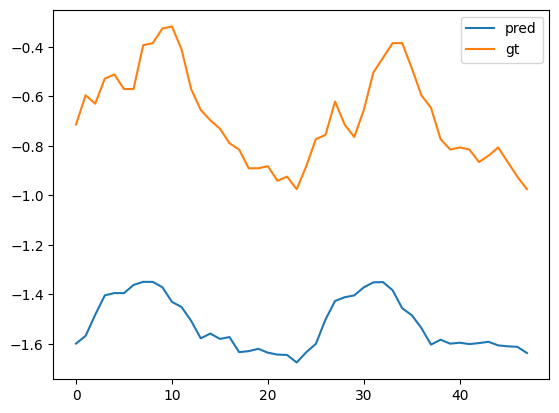

In [58]:
model = Informer.load_from_checkpoint('/home/jan/Scripts/informer/tb_logs/informer/version_35/checkpoints/epoch=37-step=14326.ckpt', hparams=hparams_struct)
pred = trainer.predict(model, datamodule=dm)
pred_output = pred[10][0][0, -48:]
pred_target = pred[10][1][0]
print(F.mse_loss(input=pred_output, target=pred_target))
print(F.l1_loss(input=pred_output, target=pred_target))
plt.plot(pred_output, label='pred')
plt.plot(pred_target, label='gt')
plt.legend()
plt.show()



In [14]:
def objective(trial: optuna.trial.Trial):
    hparams_struct = Hparams()
    hparams_struct.lr = trial.suggest_float('lr', 1e-6, 1e-3, log=True)
    hparams_struct.dropout = trial.suggest_float('dropout', 0, 0.8)
    hparams_struct.regularization = trial.suggest_float('reg', 0, 0.5)


    dm = DataModule(hparams_struct)
    informer = Informer(hparams_struct)
    trainer = Trainer(max_epochs=50, logger=[tb_logger], callbacks=[PyTorchLightningPruningCallback(trial, 'val/mse_loss')], gradient_clip_val=1)
    trainer.fit(informer, datamodule=dm)


    return trainer.callback_metrics["val/mse_loss"].item()

if hparams_struct.tune_hparams:
    study = optuna.create_study(storage="sqlite:///optuna.sqlite3", study_name="informer", load_if_exists=True)
    study.optimize(objective, n_trials=15)

